In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from venn_abers.venn_abers import VennAbersCV

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [3]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

pre_2020    = df[df["dataset"].isin(["HSE 2017", "HSE 2018", "HSE 2019"])].copy()
daphnie_23  = df[df["dataset"] == "DAPHNIE 2023"].copy()
daphnie_24  = df[df["dataset"] == "DAPHNIE 2024"].copy()

print(f"Pre-2020 HSE:  n = {len(pre_2020):,}")
print(f"DAPHNIE 2023:  n = {len(daphnie_23):,}")
print(f"DAPHNIE 2024:  n = {len(daphnie_24):,}")

Pre-2020 HSE:  n = 24,374
DAPHNIE 2023:  n = 1,657
DAPHNIE 2024:  n = 5,237


## Density Ratio Estimation

### Rationale

We want to re-weight each DAPHNIE observation so that its weighted distribution matches
pre-2020 HSE. The weight for observation $i$ is the density ratio:

$$w(x_i) = \frac{P_{\text{HSE}}(x_i)}{P_{\text{DAPHNIE}}(x_i)}$$

**Classifier-based estimation.** Pool DAPHNIE (label 0) and pre-2020 HSE (label 1) and
train a binary classifier. With `class_weight='balanced'`, the classifier equalises the
prior on both classes, so Bayes' theorem gives:

$$w(x) = \frac{\hat{p}(x)}{1 - \hat{p}(x)}$$

where $\hat{p}(x) = P(\text{HSE} \mid x)$ is the predicted probability. No sample-size
correction is needed because the balanced weighting already equalises the priors.

Weights are normalized to mean 1 and clipped at the 99th percentile to prevent a small
number of extreme values from dominating the reweighted estimates.

### Classifiers

- **Logistic regression** — primary model. Interpretable (coefficients show which
  variables drive the shift), well-calibrated, and directly analogous to propensity
  score weighting. Requires median imputation for missing values.
- **Gradient boosting** (`HistGradientBoostingClassifier`) — robustness check. Captures
  non-linear interactions and handles missing values natively. If AUC is substantially
  higher than logistic regression, residual non-linearity in the density ratio should be
  investigated.

### Evaluation

Cross-validated AUC measures how well the classifier separates the two distributions.
An AUC of 0.5 means the distributions are indistinguishable; AUC near 1 means they are
very different. After reweighting, we re-run the SMD comparison — all variables should
fall below $|\text{SMD}| = 0.1$ if the reweighting worked.

In [4]:
# Confirmed predictor set (Apr 2026, PI decisions).
# eth4cat_* dummies replaced by binary eth2cat; edu_cat_2, meds_num, ill_dis added.
# Excluded: obese (measurement shift nurse vs self-reported), resp/skin (missing HSE 2019),
#   alcohol_yr (skip-logic artefact), PA_vig/PA_mod (DAPHNIE 2023 only).
# smoke_ever: within-HSE inconsistency resolved, but 10.3% missing in DAPHNIE 2024 — deferred.
FEATURES = [
    "Sex", "age7cat",
    "eth2cat",
    "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed",
    "edu_cat_2",
    "smoke_ecig", "diabetes",
    "meds_num", "ill_dis",
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features ({len(FEATURES)}):")
print(FEATURES)

Features (13):
['Sex', 'age7cat', 'eth2cat', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis']


In [5]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    s, w = series[mask], weights[mask]
    return np.average(s, weights=w)


def weighted_var(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() < 2:
        return np.nan
    s, w = series[mask], weights[mask]
    mu = np.average(s, weights=w)
    return np.average((s - mu) ** 2, weights=w)


def compute_smd(source_series, source_weights, target_series, target_weights):
    mu_s = weighted_mean(source_series, source_weights)
    mu_t = weighted_mean(target_series, target_weights)
    if np.isnan(mu_s) or np.isnan(mu_t):
        return np.nan
    var_s = weighted_var(source_series, source_weights)
    var_t = weighted_var(target_series, target_weights)
    if np.isnan(var_s) or np.isnan(var_t):
        return np.nan
    pooled_sd = np.sqrt((var_s + var_t) / 2)
    if pooled_sd == 0:
        return np.nan
    return (mu_s - mu_t) / pooled_sd

In [6]:
class VennAbersWrapper(VennAbersCV):
    """
    VennAbersCV with DataFrame-safe fit/predict_proba.
    VennAbersCV uses integer-positional indexing internally, which breaks on
    pandas DataFrames with named columns — this wrapper converts inputs to numpy.
    """
    def fit(self, X, y, **kwargs):
        return super().fit(np.asarray(X), np.asarray(y), **kwargs)

    def predict_proba(self, X, **kwargs):
        return super().predict_proba(np.asarray(X), **kwargs)


def fit_classifiers(daphnie_df, hse_df, features):
    """
    Pool DAPHNIE (label=0) and HSE (label=1), fit six classifier variants
    (raw + two calibrated methods for both LR and HGB).

    All models use class_weight='balanced', equalising the prior on both classes.
    The density ratio is therefore w(x) = p_hat/(1-p_hat) for all variants,
    including calibrated ones — no sample-size correction needed.

    Returns a dict of fitted models, 5-fold CV AUC for the two base classifiers,
    and the pooled feature matrix X and labels y.
    """
    src = daphnie_df[features].copy().assign(_label=0)
    tgt = hse_df[features].copy().assign(_label=1)
    pooled = pd.concat([src, tgt], ignore_index=True)

    X, y = pooled[features], pooled["_label"]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    lr_proto = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=42
        )),
    ])
    hgb_proto = HistGradientBoostingClassifier(
        max_iter=300, class_weight="balanced", random_state=42
    )

    # CV AUC on prototype classifiers (cross_val_score clones internally)
    auc_lr  = cross_val_score(lr_proto,  X, y, cv=cv, scoring="roc_auc")
    auc_hgb = cross_val_score(hgb_proto, X, y, cv=cv, scoring="roc_auc")

    models = {
        "LR":               clone(lr_proto),
        "LR + Platt":       CalibratedClassifierCV(clone(lr_proto),  method="sigmoid",  cv=5),
        "LR + Venn-Abers":  VennAbersWrapper(clone(lr_proto),  inductive=False, n_splits=5, shuffle=True, random_state=42),
        "HGB":              clone(hgb_proto),
        "HGB + Isotonic":   CalibratedClassifierCV(clone(hgb_proto), method="isotonic", cv=5),
        "HGB + Venn-Abers": VennAbersWrapper(clone(hgb_proto), inductive=False, n_splits=5, shuffle=True, random_state=42),
    }

    for clf in models.values():
        clf.fit(X, y)

    return models, auc_lr, auc_hgb, X, y


def compute_weights(clf, daphnie_X, clip_percentile=99):
    """
    Density ratio weights for DAPHNIE observations.
    w(x) = p_hat / (1 - p_hat), normalised to mean 1, clipped at clip_percentile.
    Works with any sklearn-compatible classifier.
    """
    p_hat = clf.predict_proba(daphnie_X)[:, 1]  # P(HSE | x) under balanced prior
    eps = 1e-8
    w = p_hat / (1 - p_hat + eps)
    w = w / w.mean()

    clip_val = np.percentile(w, clip_percentile)
    n_clipped = (w > clip_val).sum()
    w = np.clip(w, 0, clip_val)
    w = w / w.mean()

    n_eff = w.sum() ** 2 / (w ** 2).sum()
    return w, clip_val, n_clipped, n_eff

In [7]:
MODEL_COLORS = {
    "LR":               "#d62728",
    "LR + Platt":       "#ff7f0e",
    "LR + Venn-Abers":  "#e377c2",
    "HGB":              "#1f77b4",
    "HGB + Isotonic":   "#17becf",
    "HGB + Venn-Abers": "#2ca02c",
}

waves = {
    "DAPHNIE 2023": daphnie_23,
    "DAPHNIE 2024": daphnie_24,
}

results = {}

for wave, daphnie_df in waves.items():
    n_src, n_tgt = len(daphnie_df), len(pre_2020)
    print(f"\n{'='*60}")
    print(f"{wave}  (n={n_src:,})  vs  pre-2020 HSE  (n={n_tgt:,})")
    print(f"Class ratio  DAPHNIE:HSE = 1:{n_tgt/n_src:.1f}")
    print(f"{'='*60}")

    models, auc_lr, auc_hgb, X, y = fit_classifiers(daphnie_df, pre_2020, FEATURES)

    print(f"\n  Base model AUC (5-fold CV):")
    print(f"    LR  : {auc_lr.mean():.3f}  (± {auc_lr.std():.3f})")
    print(f"    HGB : {auc_hgb.mean():.3f}  (± {auc_hgb.std():.3f})")

    X_daphnie = daphnie_df[FEATURES]
    weights = {}
    print(f"\n  Importance weight diagnostics (99th-pct clip):")
    print(f"  {'Model':<25}  {'clip':>6}  {'n_clip':>8}  {'ESS':>14}")
    for name, clf in models.items():
        w, clip_val, n_clip, n_eff = compute_weights(clf, X_daphnie)
        weights[name] = w
        print(f"  {name:<25}  {clip_val:>6.2f}  {n_clip:>5} ({100*n_clip/n_src:.1f}%)  "
              f"{n_eff:>6.0f}/{n_src} ({100*n_eff/n_src:.1f}%)")

    results[wave] = {
        "df":      daphnie_df.copy(),
        "models":  models,
        "weights": weights,
        "X":       X,
        "y":       y,
        "auc_lr":  auc_lr,
        "auc_hgb": auc_hgb,
    }


DAPHNIE 2023  (n=1,657)  vs  pre-2020 HSE  (n=24,374)
Class ratio  DAPHNIE:HSE = 1:14.7

  Base model AUC (5-fold CV):
    LR  : 0.725  (± 0.009)
    HGB : 0.881  (± 0.010)

  Importance weight diagnostics (99th-pct clip):
  Model                        clip    n_clip             ESS
  LR                           7.36     14 (0.8%)     695/1657 (41.9%)
  LR + Platt                   4.59     15 (0.9%)    1069/1657 (64.5%)
  LR + Venn-Abers              6.46     13 (0.8%)     762/1657 (46.0%)
  HGB                          8.50     17 (1.0%)     593/1657 (35.8%)
  HGB + Isotonic               3.73     17 (1.0%)    1001/1657 (60.4%)
  HGB + Venn-Abers             9.63     17 (1.0%)     496/1657 (30.0%)

DAPHNIE 2024  (n=5,237)  vs  pre-2020 HSE  (n=24,374)
Class ratio  DAPHNIE:HSE = 1:4.7

  Base model AUC (5-fold CV):
    LR  : 0.648  (± 0.007)
    HGB : 0.819  (± 0.009)

  Importance weight diagnostics (99th-pct clip):
  Model                        clip    n_clip             ESS
  L

/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


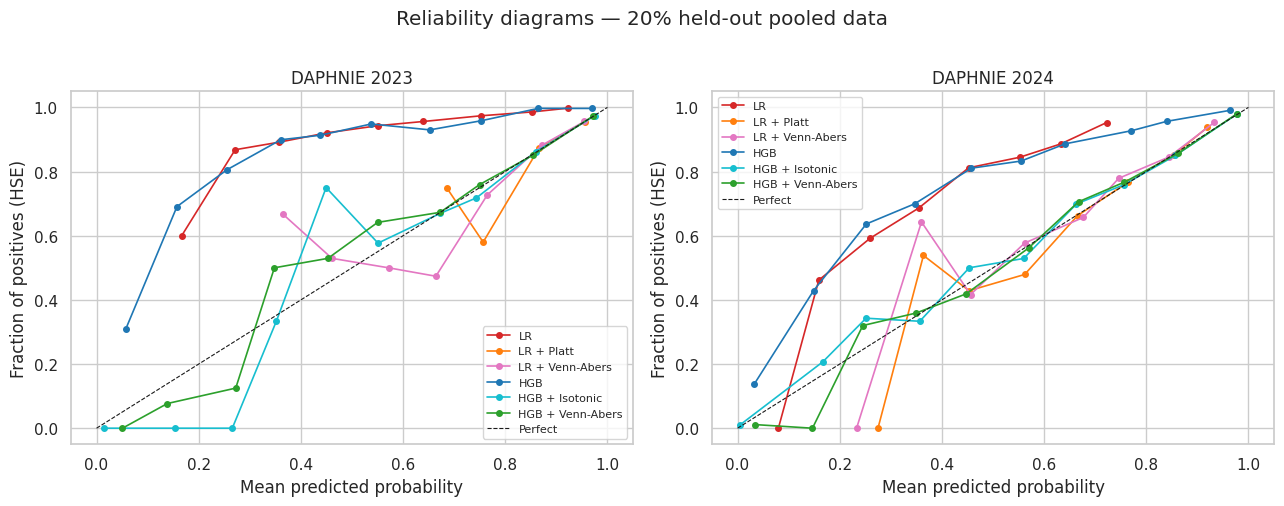


DAPHNIE 2023 — calibration metrics (held-out 20%):


,Brier score,ECE
Model,,
LR,0.214,0.359
LR + Platt,0.057,0.004
LR + Venn-Abers,0.056,0.005
HGB,0.145,0.226
HGB + Isotonic,0.046,0.003
HGB + Venn-Abers,0.046,0.004



DAPHNIE 2024 — calibration metrics (held-out 20%):


,Brier score,ECE
Model,,
LR,0.231,0.302
LR + Platt,0.138,0.006
LR + Venn-Abers,0.137,0.007
HGB,0.178,0.217
HGB + Isotonic,0.112,0.010
HGB + Venn-Abers,0.112,0.011


In [8]:
def ece_score(y_true, y_prob, n_bins=10):
    """Expected Calibration Error — binning-based."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        ece += mask.sum() / n * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece


def run_calibration_diagnostics(daphnie_df, hse_df, features):
    """
    Calibration assessment via a stratified 80/20 hold-out split on pooled data.
    Fits all six model variants on the 80% training split, evaluates reliability,
    Brier score, and ECE on the held-out 20%.
    The held-out set is not used for any weight computation — diagnostics only.
    """
    src = daphnie_df[features].copy().assign(_label=0)
    tgt = hse_df[features].copy().assign(_label=1)
    pooled = pd.concat([src, tgt], ignore_index=True)
    X_all, y_all = pooled[features], pooled["_label"]

    X_tr, X_cal, y_tr, y_cal = train_test_split(
        X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
    )

    lr_proto = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ])
    hgb_proto = HistGradientBoostingClassifier(
        max_iter=300, class_weight="balanced", random_state=42
    )

    diag_models = {
        "LR":               clone(lr_proto),
        "LR + Platt":       CalibratedClassifierCV(clone(lr_proto),  method="sigmoid",  cv=5),
        "LR + Venn-Abers":  VennAbersWrapper(clone(lr_proto),  inductive=False, n_splits=5, shuffle=True, random_state=42),
        "HGB":              clone(hgb_proto),
        "HGB + Isotonic":   CalibratedClassifierCV(clone(hgb_proto), method="isotonic", cv=5),
        "HGB + Venn-Abers": VennAbersWrapper(clone(hgb_proto), inductive=False, n_splits=5, shuffle=True, random_state=42),
    }

    for clf in diag_models.values():
        clf.fit(X_tr, y_tr)

    probs, rows = {}, []
    for name, clf in diag_models.items():
        p = clf.predict_proba(X_cal)[:, 1]
        probs[name] = p
        rows.append({
            "Model":       name,
            "Brier score": brier_score_loss(y_cal, p),
            "ECE":         ece_score(y_cal.values, p),
        })

    return probs, y_cal.values, pd.DataFrame(rows).set_index("Model")


# Run diagnostics once per wave
cal_diagnostics = {}
for wave, res in results.items():
    probs, y_cal, metrics = run_calibration_diagnostics(res["df"], pre_2020, FEATURES)
    cal_diagnostics[wave] = {"probs": probs, "y_cal": y_cal, "metrics": metrics}

# Reliability diagrams
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (wave, cd) in zip(axes, cal_diagnostics.items()):
    for name, p in cd["probs"].items():
        frac, mean_pred = calibration_curve(cd["y_cal"], p, n_bins=10, strategy="uniform")
        ax.plot(mean_pred, frac, marker="o", markersize=4, linewidth=1.2,
                label=name, color=MODEL_COLORS[name])
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect")
    ax.set_title(wave)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives (HSE)")
    ax.legend(fontsize=8)

fig.suptitle("Reliability diagrams — 20% held-out pooled data", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "calibration_reliability.png", dpi=150, bbox_inches="tight")
plt.show()

# Brier score and ECE summary
for wave, cd in cal_diagnostics.items():
    print(f"\n{wave} — calibration metrics (held-out 20%):")
    display(cd["metrics"].round(4))

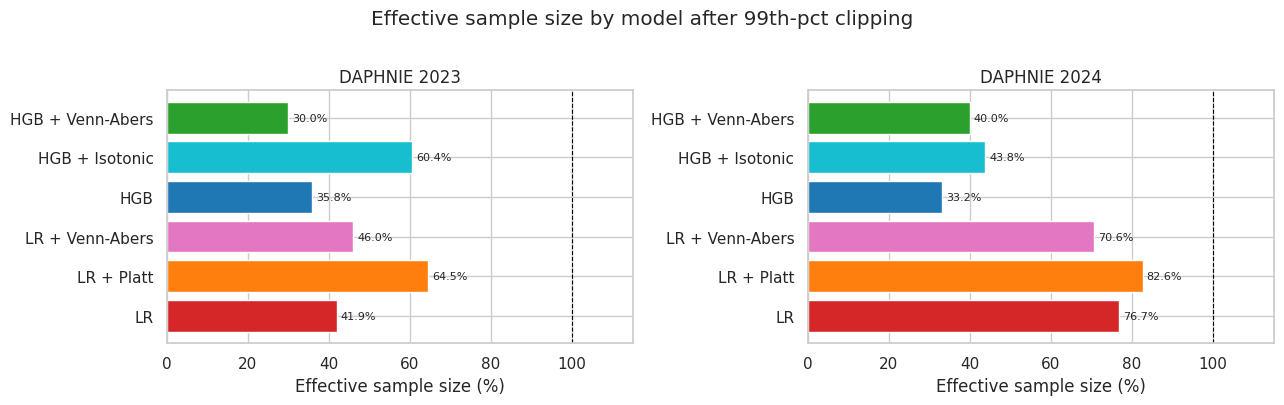

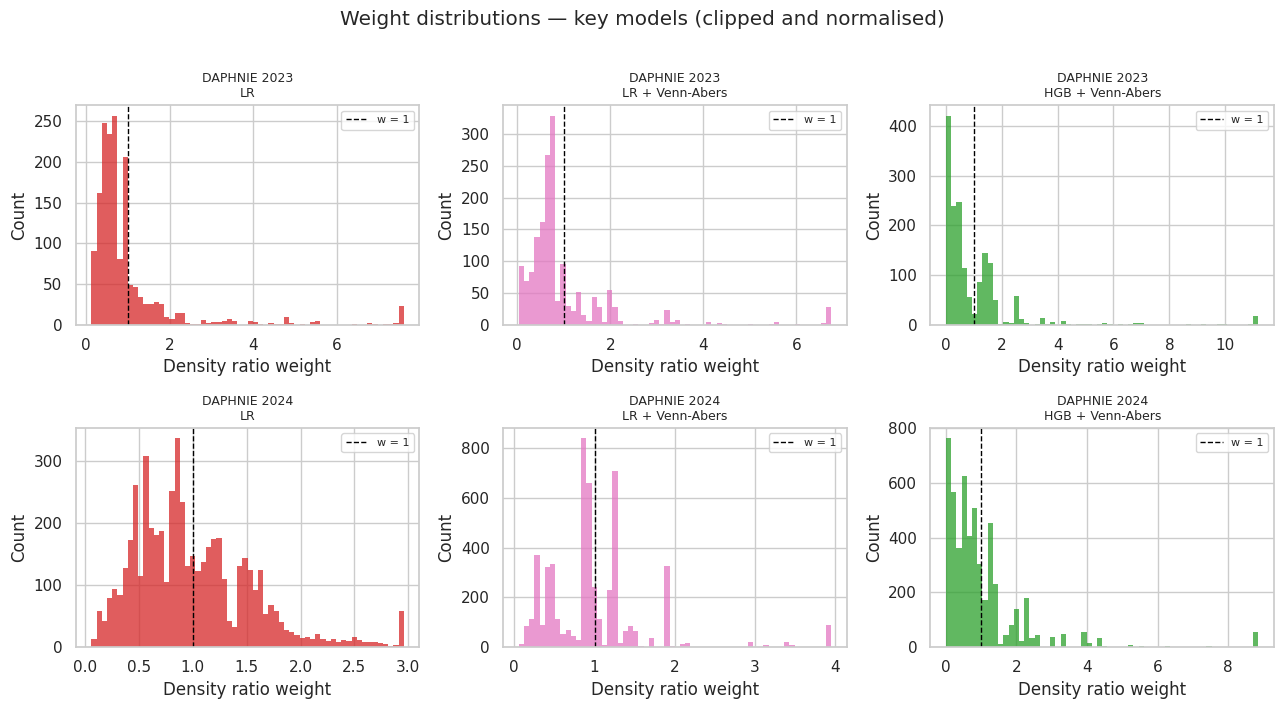

In [9]:
# ESS comparison across all six models (bar chart)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (wave, res) in zip(axes, results.items()):
    n_src = len(res["df"])
    names = list(res["weights"].keys())
    ess_pct = [res["weights"][n].sum()**2 / (res["weights"][n]**2).sum() / n_src * 100
               for n in names]
    ax.barh(names, ess_pct, color=[MODEL_COLORS[n] for n in names])
    ax.axvline(100, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Effective sample size (%)")
    ax.set_title(wave)
    ax.set_xlim(0, 115)
    for i, v in enumerate(ess_pct):
        ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=8)

fig.suptitle("Effective sample size by model after 99th-pct clipping", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "ess_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Weight distributions — key models only: LR, LR+VA, HGB+VA
KEY_DIST = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=False)
for row, (wave, res) in enumerate(results.items()):
    for col, name in enumerate(KEY_DIST):
        ax = axes[row, col]
        w = res["weights"][name]
        ax.hist(w, bins=60, color=MODEL_COLORS[name], edgecolor="none", alpha=0.75)
        ax.axvline(1.0, color="black", linewidth=1.0, linestyle="--", label="w = 1")
        ax.set_title(f"{wave}\n{name}", fontsize=9)
        ax.set_xlabel("Density ratio weight")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

fig.suptitle("Weight distributions — key models (clipped and normalised)", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "density_ratio_weight_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

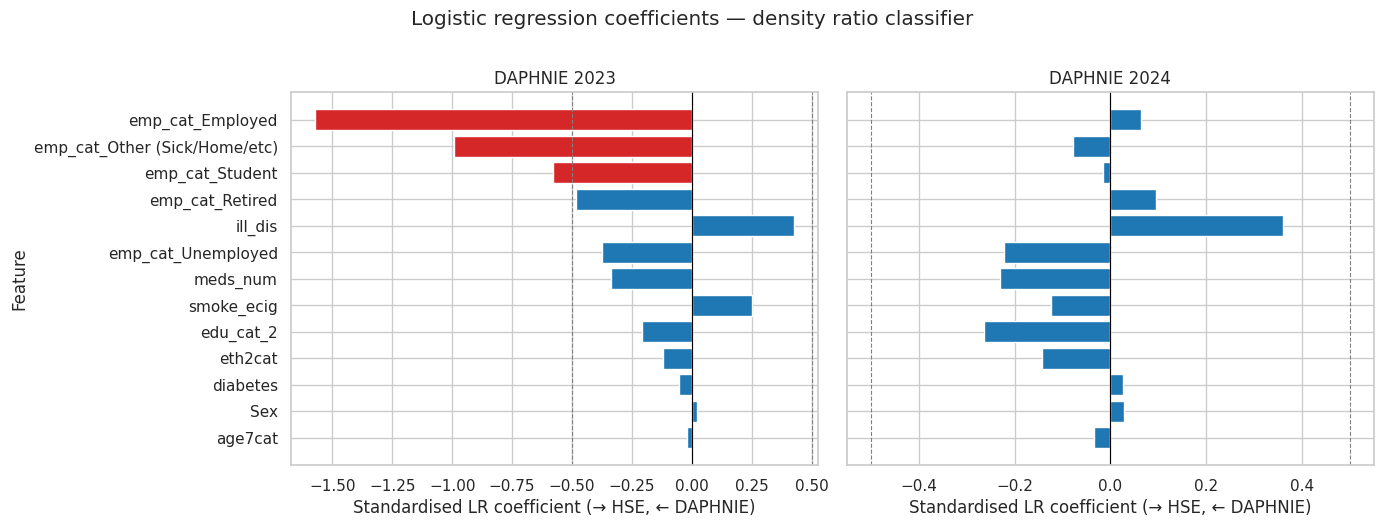


DAPHNIE 2023 — LR coefficients (standardised):


,coefficient,|coefficient|
emp_cat_Employed,-1.573,1.573
emp_cat_Other (Sick/Home/etc),-0.993,0.993
emp_cat_Student,-0.579,0.579
emp_cat_Retired,-0.483,0.483
ill_dis,0.427,0.427
emp_cat_Unemployed,-0.376,0.376
meds_num,-0.337,0.337
smoke_ecig,0.251,0.251
edu_cat_2,-0.208,0.208
eth2cat,-0.118,0.118



DAPHNIE 2024 — LR coefficients (standardised):


,coefficient,|coefficient|
ill_dis,0.361,0.361
edu_cat_2,-0.264,0.264
meds_num,-0.231,0.231
emp_cat_Unemployed,-0.223,0.223
eth2cat,-0.144,0.144
smoke_ecig,-0.123,0.123
emp_cat_Retired,0.095,0.095
emp_cat_Other (Sick/Home/etc),-0.079,0.079
emp_cat_Employed,0.064,0.064
age7cat,-0.035,0.035


In [10]:
# LR coefficient inspection — which features drive the separation?
# Coefficients are on the standardised scale, so magnitudes are directly comparable.
# Positive = feature pushes towards HSE (label=1); negative = pushes towards DAPHNIE.

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(FEATURES) * 0.4)), sharey=True)

for ax, (wave, res) in zip(axes, results.items()):
    clf  = res["models"]["LR"].named_steps["clf"]
    coef = pd.Series(clf.coef_[0], index=FEATURES).sort_values(key=abs)
    colors = ["#d62728" if abs(v) > 0.5 else "#1f77b4" for v in coef]
    ax.barh(coef.index, coef.values, color=colors)
    ax.axvline(0,    color="black", linewidth=0.8)
    ax.axvline( 0.5, color="grey",  linewidth=0.8, linestyle="--")
    ax.axvline(-0.5, color="grey",  linewidth=0.8, linestyle="--")
    ax.set_title(f"{wave}")
    ax.set_xlabel("Standardised LR coefficient (→ HSE, ← DAPHNIE)")

axes[0].set_ylabel("Feature")
fig.suptitle("Logistic regression coefficients — density ratio classifier", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

for wave, res in results.items():
    clf  = res["models"]["LR"].named_steps["clf"]
    tbl = (
        pd.DataFrame({
            "coefficient":   clf.coef_[0],
            "|coefficient|": np.abs(clf.coef_[0]),
        }, index=FEATURES)
        .sort_values("|coefficient|", ascending=False)
    )
    print(f"\n{wave} — LR coefficients (standardised):")
    display(tbl.round(3))

In [11]:
# Balance check: SMD before and after reweighting, for key models
KEY_BALANCE = ["LR", "LR + Venn-Abers", "HGB", "HGB + Venn-Abers"]

hse_wt = pre_2020["wt_int"].fillna(1.0)
balance = {}

for wave, res in results.items():
    ddf = res["df"]
    svy_wt = ddf["svy_wt"].fillna(1.0)

    smds = {}
    for col in FEATURES:
        row = {"Before": compute_smd(ddf[col], svy_wt, pre_2020[col], hse_wt)}
        for name in KEY_BALANCE:
            w = res["weights"][name]
            row[f"After: {name}"] = compute_smd(ddf[col], svy_wt * w, pre_2020[col], hse_wt)
        smds[col] = row

    balance[wave] = pd.DataFrame(smds).T

for wave, tbl in balance.items():
    print(f"\n{wave} — covariate balance (SMD):")
    display(
        tbl.dropna(how="all")
        .sort_values("Before", key=abs, ascending=False)
        .round(3)
    )


DAPHNIE 2023 — covariate balance (SMD):


,Before,After: LR,After: LR + Venn-Abers,After: HGB,After: HGB + Venn-Abers
emp_cat_Retired,-0.521,0.082,0.029,-0.596,-0.575
emp_cat_Employed,0.429,-0.030,0.001,0.335,0.305
edu_cat_2,0.316,0.020,0.015,0.118,0.077
ill_dis,-0.281,-0.114,-0.082,0.009,0.084
smoke_ecig,-0.251,-0.011,-0.016,-0.013,-0.031
eth2cat,0.171,0.033,0.018,0.015,-0.015
emp_cat_Student,-0.140,-0.086,-0.082,-0.086,-0.061
emp_cat_Unemployed,-0.081,-0.027,-0.030,-0.044,-0.057
meds_num,0.065,-0.185,-0.178,-0.168,-0.129
emp_cat_Other (Sick/Home/etc),0.063,0.023,0.045,0.179,0.191



DAPHNIE 2024 — covariate balance (SMD):


,Before,After: LR,After: LR + Venn-Abers,After: HGB,After: HGB + Venn-Abers
edu_cat_2,0.257,-0.035,-0.047,0.006,-0.015
emp_cat_Unemployed,0.237,-0.015,-0.018,-0.010,0.016
eth2cat,0.163,-0.075,-0.106,-0.098,-0.142
ill_dis,-0.153,0.108,0.151,0.141,0.143
emp_cat_Employed,-0.086,-0.041,-0.045,-0.082,-0.106
emp_cat_Student,-0.061,-0.110,-0.106,-0.164,-0.169
smoke_ecig,0.060,-0.027,-0.028,-0.063,-0.046
emp_cat_Other (Sick/Home/etc),0.052,0.038,0.026,0.036,0.038
Sex,0.048,0.073,0.087,0.072,0.077
age7cat,0.041,0.156,0.158,0.273,0.276


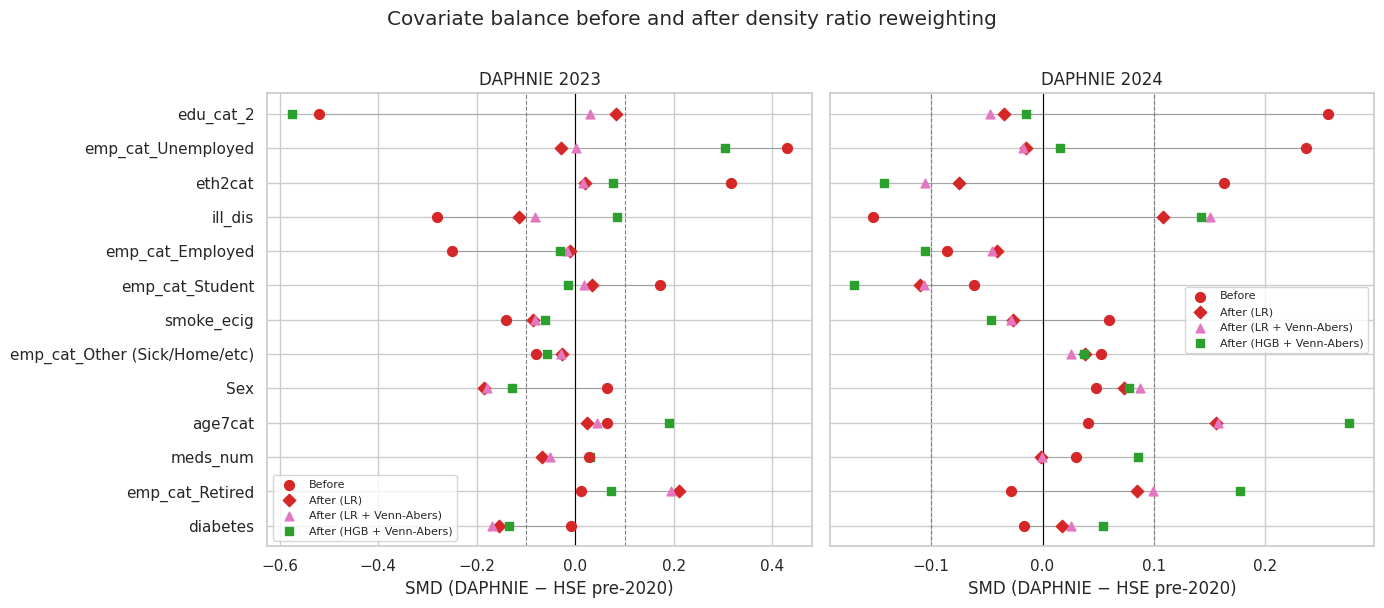


DAPHNIE 2023:
  Before:              7 variables |SMD| > 0.1
  After (LR                    ): 4 variables |SMD| > 0.1
  After (LR + Venn-Abers       ): 3 variables |SMD| > 0.1
  After (HGB + Venn-Abers      ): 5 variables |SMD| > 0.1

DAPHNIE 2024:
  Before:              4 variables |SMD| > 0.1
  After (LR                    ): 3 variables |SMD| > 0.1
  After (LR + Venn-Abers       ): 4 variables |SMD| > 0.1
  After (HGB + Venn-Abers      ): 6 variables |SMD| > 0.1


In [12]:
# Love plot — Before vs three "after" variants: LR, LR+VA, HGB+VA
KEY_LOVE    = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]
LOVE_MARKERS = {"LR": "D", "LR + Venn-Abers": "^", "HGB + Venn-Abers": "s"}

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(FEATURES) * 0.45)), sharey=True)

for ax, (wave, tbl) in zip(axes, balance.items()):
    tbl_plot = tbl.dropna(subset=["Before"]).copy()
    order    = tbl_plot["Before"].abs().sort_values().index
    y_pos    = np.arange(len(order))
    before   = tbl_plot.loc[order, "Before"]

    ax.scatter(before, y_pos, color="#d62728", zorder=4, s=50, label="Before")

    for name in KEY_LOVE:
        col   = f"After: {name}"
        after = tbl_plot.loc[order, col]
        ax.scatter(after, y_pos, color=MODEL_COLORS[name], zorder=3, s=40,
                   marker=LOVE_MARKERS[name], label=f"After ({name})")
        for i, (b, a) in enumerate(zip(before, after)):
            ax.plot([b, a], [i, i], color="grey", linewidth=0.5, zorder=2, alpha=0.4)

    ax.axvline(0,    color="black", linewidth=0.8)
    ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
    ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order)
    ax.set_xlabel("SMD (DAPHNIE − HSE pre-2020)")
    ax.set_title(wave)
    ax.legend(fontsize=8)

fig.suptitle("Covariate balance before and after density ratio reweighting", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "balance_pre_post_reweighting.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary counts
for wave, tbl in balance.items():
    print(f"\n{wave}:")
    print(f"  Before:              {tbl['Before'].abs().gt(0.1).sum()} variables |SMD| > 0.1")
    for name in KEY_LOVE:
        col = f"After: {name}"
        print(f"  After ({name:<22}): {tbl[col].abs().gt(0.1).sum()} variables |SMD| > 0.1")